In [2]:
!pip install missingno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

df = pd.read_csv("../data/processed/tamilnadu_nfhs5_merged.csv")

print("Shape:", df.shape)
print("\nColumn list:")
print(df.columns.tolist())

Shape: (6498, 13)

Column list:
['caseid', 'midx', 'v001', 'v002', 'state', 'stunting_haz', 'mother_education', 'wealth_index', 'mother_bmi', 'hhid', 'toilet_type', 'electricity', 'share_toilet']


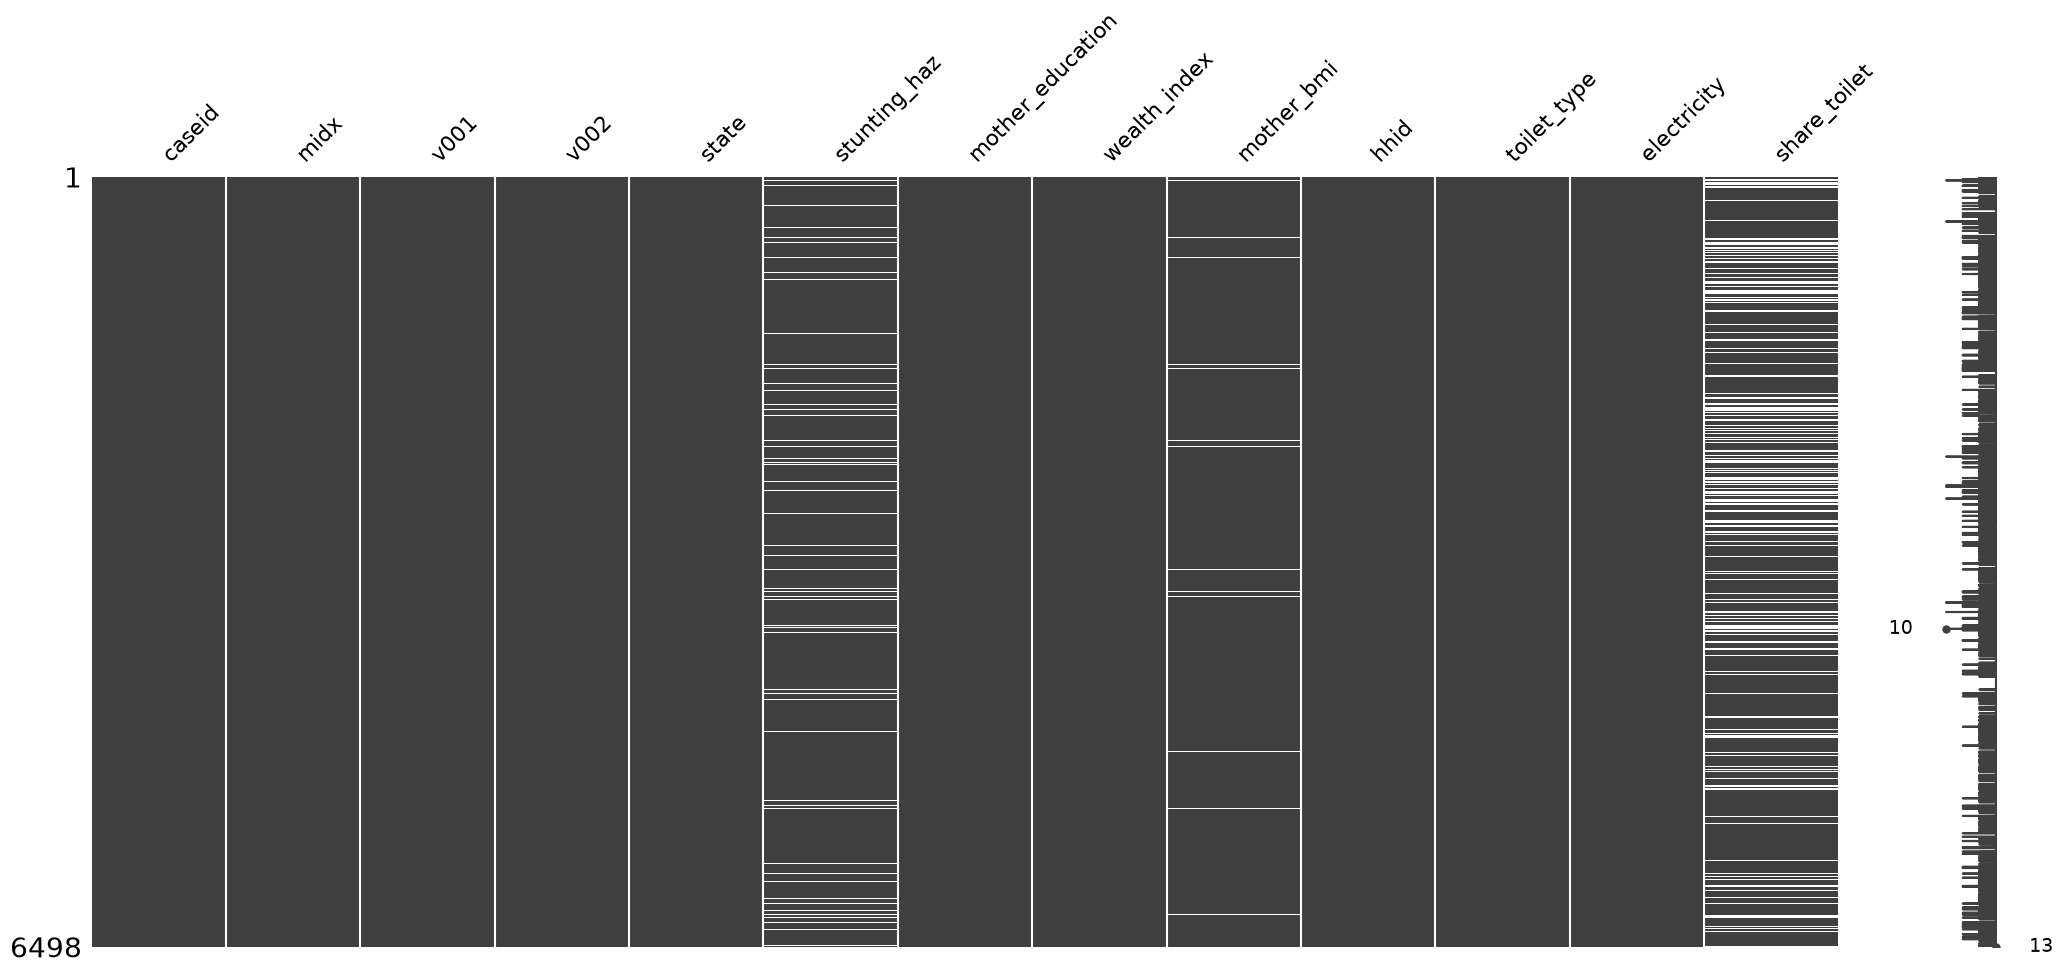

share_toilet    23.1
stunting_haz     7.1
mother_bmi       2.2
dtype: float64


In [3]:
msno.matrix(df)
plt.savefig("../outputs/figures/missing_data_matrix.png", bbox_inches="tight")
plt.show()

# Numbers: which columns are missing and how much
missing_pct = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

In [4]:
print("=== CLASS BALANCE ===")

if "stunting_label" not in df.columns:
    if "stunting_haz" not in df.columns:
        raise KeyError("Neither 'stunting_label' nor 'stunting_haz' exists in df")

    df["stunting_label"] = np.where(df["stunting_haz"] < -200, "Stunted", "Not stunted")
    print("Derived stunting_label from stunting_haz using HAZ < -2.00 as the stunting threshold.")

print(df["stunting_label"].value_counts())
print()
print(df["stunting_label"].value_counts(normalize=True) * 100)

=== CLASS BALANCE ===
Derived stunting_label from stunting_haz using HAZ < -2.00 as the stunting threshold.
stunting_label
Not stunted    4981
Stunted        1517
Name: count, dtype: int64

stunting_label
Not stunted    76.654355
Stunted        23.345645
Name: proportion, dtype: float64


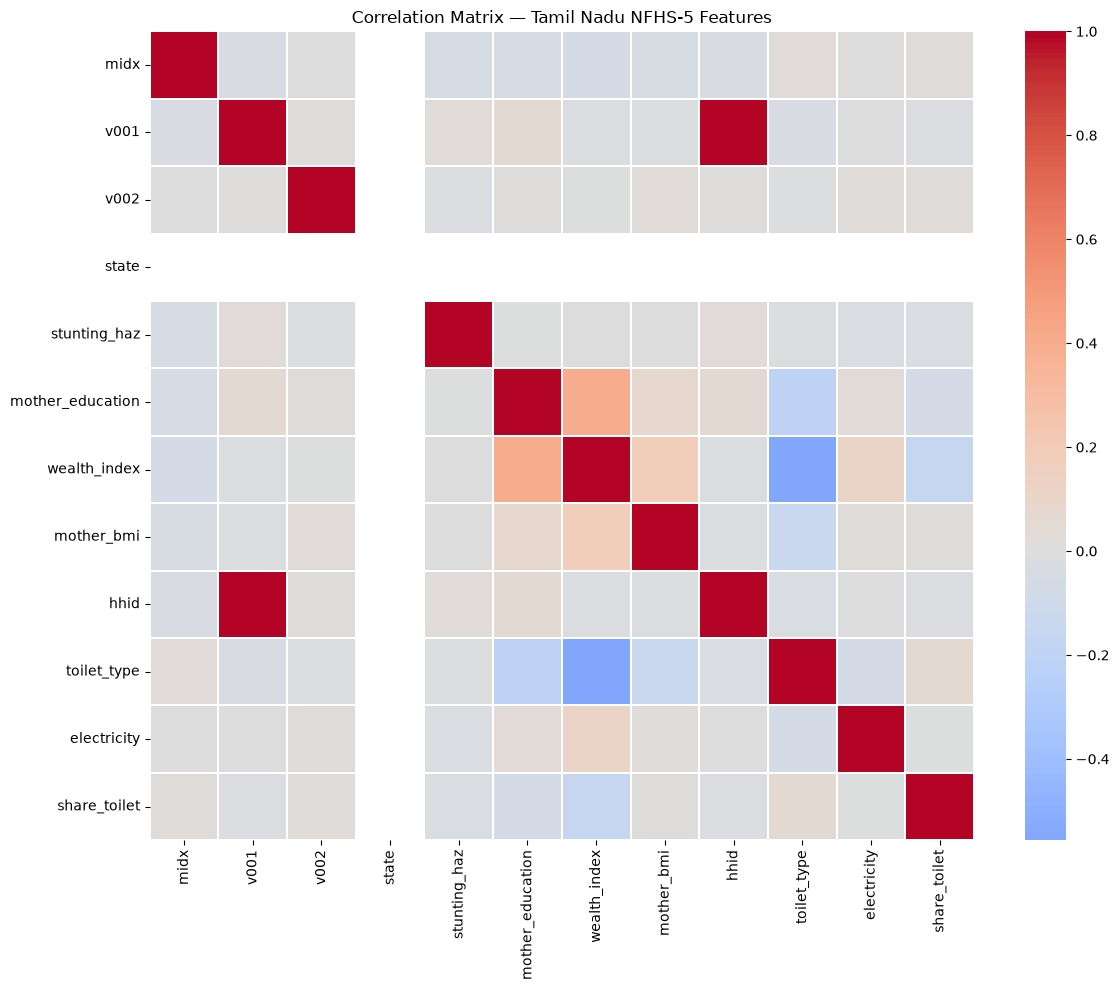

In [5]:
numeric_df = df.select_dtypes(include=["number"])
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Matrix — Tamil Nadu NFHS-5 Features")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_matrix.png", dpi=150)
plt.show()

In [6]:
df["stunting_flag"] = (df["stunting_label"] == "Stunted").astype(int)

# Stunting rate by wealth index
print("=== STUNTING RATE BY WEALTH INDEX ===")
print((df.groupby("wealth_index")["stunting_flag"].mean() * 100).round(1))

# Stunting rate by mother's education
print("\n=== STUNTING RATE BY MOTHER'S EDUCATION ===")
print((df.groupby("mother_education")["stunting_flag"].mean() * 100).round(1))
# mother_education: 0=no education, 1=primary, 2=secondary, 3=higher

=== STUNTING RATE BY WEALTH INDEX ===
wealth_index
1    39.3
2    28.9
3    25.6
4    21.5
5    15.9
Name: stunting_flag, dtype: float64

=== STUNTING RATE BY MOTHER'S EDUCATION ===
mother_education
0    34.9
1    27.3
2    24.8
3    20.4
Name: stunting_flag, dtype: float64


In [7]:
print("Rows before target-drop:", len(df))
df = df.dropna(subset=["stunting_label"])
print("Rows after target-drop:", len(df))

Rows before target-drop: 6498
Rows after target-drop: 6498


In [8]:
# Using YOUR chosen threshold (e.g., 40%)
MISSING_THRESHOLD = 0.40

missing_pct_vals = df.isnull().mean()
cols_to_drop = missing_pct_vals[missing_pct_vals > MISSING_THRESHOLD].index.tolist()

print("Columns dropped (>40% missing):", cols_to_drop)
df = df.drop(columns=cols_to_drop)
print("Shape after dropping:", df.shape)

Columns dropped (>40% missing): []
Shape after dropping: (6498, 15)


In [9]:
# Columns to exclude from features (IDs and target)
exclude_cols = ["stunting_label", "caseid", "hhid"]

# After dropping high-missing columns, identify types
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in exclude_cols]

C:\Users\dhanu\AppData\Local\Temp\ipykernel_23008\2031512494.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [10]:
# Categorical: fill with mode (most common value)
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numeric: fill with median (safer than mean for skewed data like wealth/income)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Confirm zero missing
print("Remaining missing values:", df.isnull().sum().sum())
# Should print: 0

Remaining missing values: 0


In [11]:
# ── Cell: Define stunted label ──────────────────────────────────────────
# Stunting is defined as HAZ < -2.0 (WHO standard)
df['stunted'] = (df['stunting_haz'] < -2.0).astype(int)
print("Stunted children:", df['stunted'].sum())
print("Total children:", len(df))
print("Stunting prevalence (%):", round(df['stunted'].mean() * 100, 2))

Stunted children: 5148
Total children: 6498
Stunting prevalence (%): 79.22


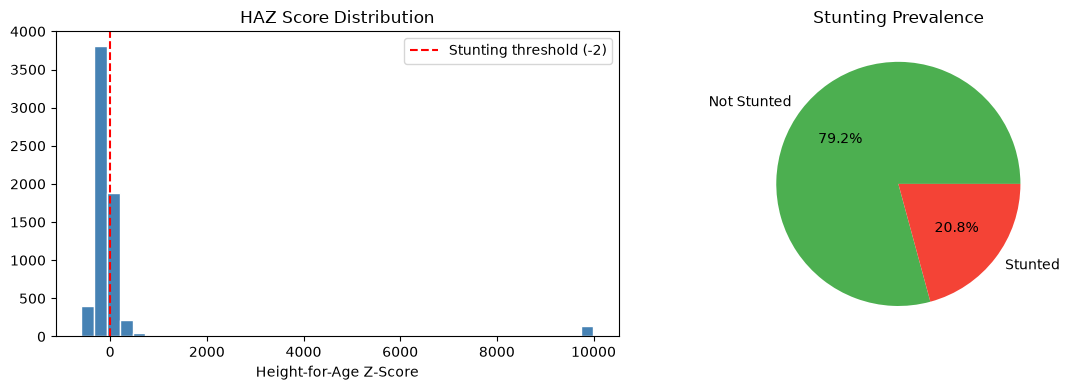

In [12]:
# ── Cell: Target distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# HAZ score distribution
axes[0].hist(df['stunting_haz'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(-2, color='red', linestyle='--', label='Stunting threshold (-2)')
axes[0].set_title('HAZ Score Distribution')
axes[0].set_xlabel('Height-for-Age Z-Score')
axes[0].legend()

# Stunted vs Not stunted pie chart
stunted_counts = df['stunted'].value_counts()
axes[1].pie(stunted_counts, labels=['Not Stunted', 'Stunted'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
axes[1].set_title('Stunting Prevalence')

plt.tight_layout()
plt.savefig('../outputs/figures/stunting_prevalence.png', dpi=150)
plt.show()

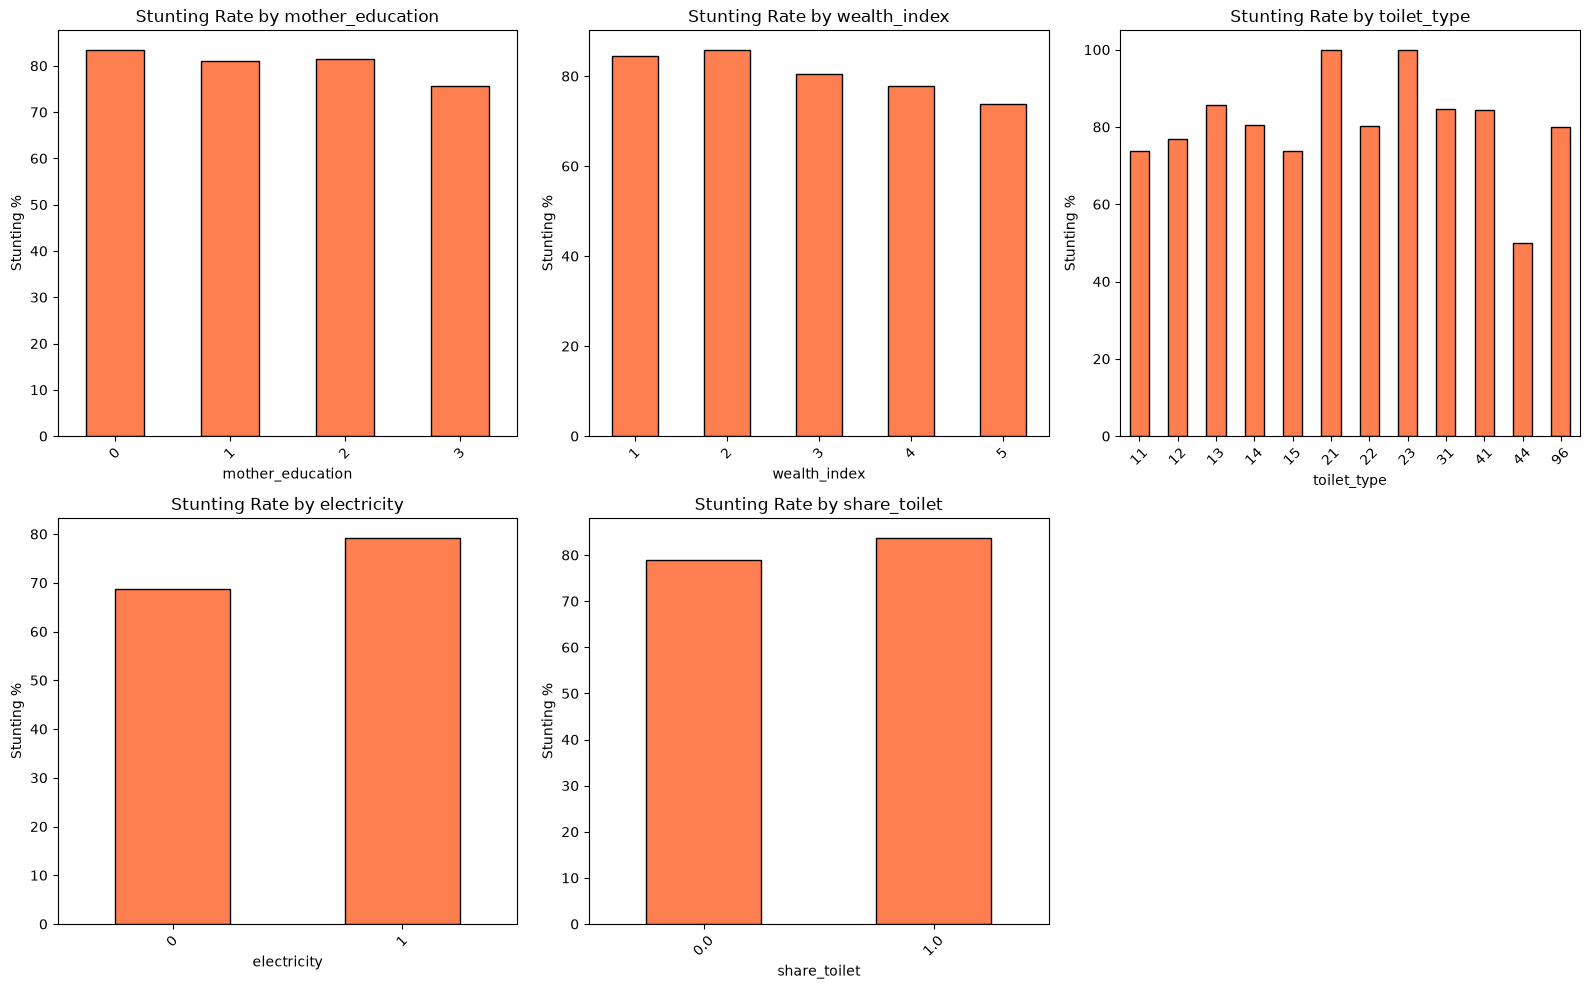

In [13]:
# ── Cell: Stunting by categorical features ──────────────────────────────
# These are your socioeconomic predictors
cat_cols = ['mother_education', 'wealth_index', 'toilet_type',
            'electricity', 'share_toilet']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    grouped = df.groupby(col)['stunted'].mean() * 100
    grouped.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'Stunting Rate by {col}')
    axes[i].set_ylabel('Stunting %')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].axis('off')  # hide unused subplot
plt.tight_layout()
plt.savefig('../outputs/figures/stunting_by_category.png', dpi=150)
plt.show()

<Figure size 700x500 with 0 Axes>

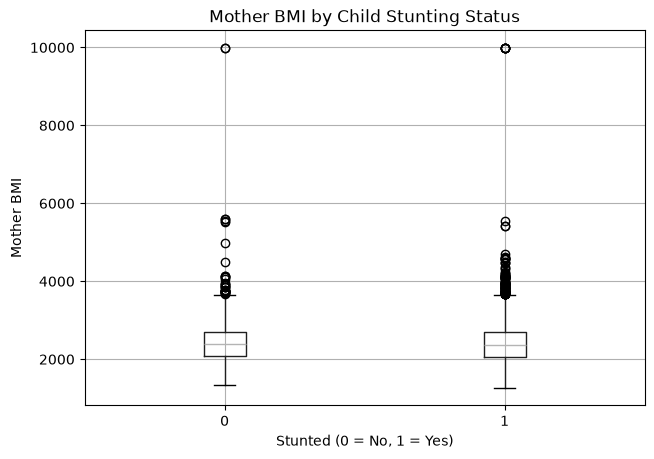

In [14]:
# ── Cell: Mother BMI vs Stunting ─────────────────────────────────────────
# Continuous feature — use boxplot to compare stunted vs not
plt.figure(figsize=(7, 5))
df.boxplot(column='mother_bmi', by='stunted', figsize=(7, 5))
plt.suptitle('')
plt.title("Mother BMI by Child Stunting Status")
plt.xlabel("Stunted (0 = No, 1 = Yes)")
plt.ylabel("Mother BMI")
plt.savefig('../outputs/figures/mother_bmi_vs_stunting.png', dpi=150)
plt.show()

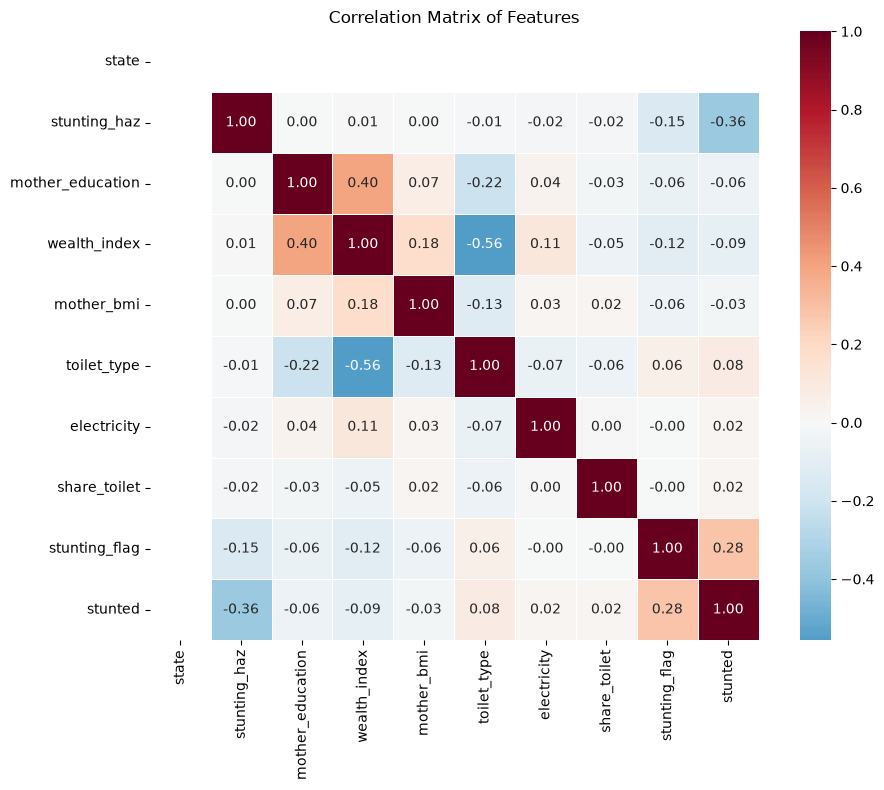

In [16]:
# ── Cell: Correlation heatmap ────────────────────────────────────────────
# Drop non-numeric / ID columns for correlation
numeric_df = df.drop(columns=['caseid', 'midx', 'v001', 'v002', 'hhid'])
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150)
plt.show()

In [17]:
# ── Cell: Missing value summary (table) ──────────────────────────────────
missing_summary = df.isnull().sum().reset_index()
missing_summary.columns = ['Column', 'Missing Count']
missing_summary['Missing %'] = (missing_summary['Missing Count'] / len(df) * 100).round(2)
print(missing_summary.sort_values('Missing %', ascending=False))

              Column  Missing Count  Missing %
0             caseid              0        0.0
1               midx              0        0.0
2               v001              0        0.0
3               v002              0        0.0
4              state              0        0.0
5       stunting_haz              0        0.0
6   mother_education              0        0.0
7       wealth_index              0        0.0
8         mother_bmi              0        0.0
9               hhid              0        0.0
10       toilet_type              0        0.0
11       electricity              0        0.0
12      share_toilet              0        0.0
13    stunting_label              0        0.0
14     stunting_flag              0        0.0
15           stunted              0        0.0
